# 04. Ensemble Learning: Bagging, Boosting, and Gradient Trees
**Algorithms Covered:**
1. **Random Forest Regression (RFR)** (Bagging + Feature Subspacing)
2. **Random Forest Classification (RFC)** (Majority Voting Ensemble)
3. **XGBoost** (Extreme Gradient Boosting with 2nd-Order Hessian Regularization)
4. **AdaBoost** (Adaptive Boosting with Exponential Loss & Weighted Weak Learners)
5. **CatBoost** (Categorical Boosting with Ordered Boosting & Oblivious Trees)

**Datasets:**
- **Regression Benchmark:** California Housing Dataset (20,640 samples, predicting median house value)
- **Classification Benchmark:** Heart Disease Dataset with Categorical & Numerical Features (`data/heart_disease.csv`)


In [1]:
# ---- Core numerical and plotting libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- California Housing dataset loader ----
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
# ---- Ensemble models (Random Forest + AdaBoost for regression and classification) ----
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
    AdaBoostRegressor,
    AdaBoostClassifier
)
# ---- Regression and classification metrics ----
from sklearn.metrics import (
    r2_score,
    root_mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)
from sklearn.preprocessing import StandardScaler

# ---- Gradient boosting libraries ----
import xgboost as xgb
import catboost as cb

# Styling setup (consistent look across all notebooks)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

np.random.seed(42)
print(f"XGBoost version:  {xgb.__version__}")
print(f"CatBoost version: {cb.__version__}")


XGBoost version:  3.4.1
CatBoost version: 1.2.10


## PART 1: Ensemble Regression Benchmark
### Dataset: California Housing
Target: Continuous median house value ($100k units).
Features: Median income, House age, Average rooms, Bedrooms, Population, Occupancy, Latitude, Longitude.


In [2]:
# ---- Load the California Housing dataset (real-world regression benchmark) ----
housing = fetch_california_housing(as_frame=True)
# Sample 5,000 rows so every ensemble trains quickly while remaining representative
df_reg = housing.frame.sample(n=5000, random_state=42)

X_reg = df_reg[housing.feature_names]   # 8 socio-economic / geographic features
y_reg = df_reg['MedHouseVal']           # target: median house value

# ---- Train/test split (80% / 20%) ----
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print(f"Regression Training Samples: {X_train_reg.shape[0]}, Test Samples: {X_test_reg.shape[0]}")
df_reg.head()


Regression Training Samples: 4000, Test Samples: 1000


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,0.47700
3024,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46,0.45800
15663,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44,5.00001
20484,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72,2.18600
9814,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93,2.78000


### 1.1 Random Forest Regression (RFR)
**Mathematical Concept:**
Bagging trains $B$ independent decision trees $\{T_b\}_{b=1}^B$ on bootstrap samples $\mathcal{D}_b^* \sim \mathcal{D}$.
At each split, only a random subset $m \le p$ features is considered to decorrelate individual trees.
The final ensemble prediction is the arithmetic mean of all tree outputs:
$$\hat{f}_{\text{RF}}(x) = \frac{1}{B}\sum_{b=1}^B T_b(x)$$
Variance reduction property: $\text{Var}(\hat{f}_{\text{RF}}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$.


### Step-by-Step Algorithm (Random Forest Regression)
1. Draw B bootstrap samples from the training data (sampling with replacement).
2. Grow one decision tree per bootstrap sample; at each split consider only a random subset of features.
3. Let every tree predict independently on the test point.
4. Average the B tree predictions: f̂_RF(x) = (1/B) Σ T_b(x).
5. Use out-of-bag samples (not drawn in a bootstrap) to estimate generalization (OOB score).


In [3]:
# ---- Random Forest Regression (bagging of decision trees) ----
# n_estimators = number of trees, oob_score = estimate accuracy from out-of-bag samples
rf_reg = RandomForestRegressor(n_estimators=150, max_depth=12, oob_score=True, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)

# ---- Predict and evaluate ----
y_pred_rf = rf_reg.predict(X_test_reg)
r2_rf = r2_score(y_test_reg, y_pred_rf)                          # explained variance (1.0 = perfect)
rmse_rf = root_mean_squared_error(y_test_reg, y_pred_rf)         # error in target units
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)              # robust average error

print(f"Random Forest Regressor Results:")
print(f" - Out-of-Bag (OOB) R² Score: {rf_reg.oob_score_:.4f}")
print(f" - Test R² Score:              {r2_rf:.4f}")
print(f" - Test RMSE:                  {rmse_rf:.4f}")
print(f" - Test MAE:                   {mae_rf:.4f}")


Random Forest Regressor Results:
 - Out-of-Bag (OOB) R² Score: 0.7513
 - Test R² Score:              0.7415
 - Test RMSE:                  0.5908
 - Test MAE:                   0.3999


### 1.2 AdaBoost Regression
**Mathematical Concept:**
AdaBoost trains weak regressors sequentially. At iteration $m$, errors are mapped to sample weights:
$$e_i^{(m)} = \frac{|y_i - \hat{y}_m(x_i)|}{\sup_j |y_j - \hat{y}_m(x_j)|}$$
Average loss $\bar{L}_m = \sum_i w_i^{(m)} e_i^{(m)}$ defines learner weight $\beta_m = \frac{\bar{L}_m}{1 - \bar{L}_m}$.
Sample weights are updated: $w_i^{(m+1)} = w_i^{(m)} \beta_m^{1 - e_i^{(m)}}$.


### Step-by-Step Algorithm (AdaBoost Regression)
1. Initialize equal weights w_i for all training samples.
2. Train a weak regressor on the weighted data.
3. Compute the relative error e_i = |y_i − ŷ_m(x_i)| / max_j |y_j − ŷ_m(x_j)|.
4. Set the learner weight β_m = L̄_m / (1 − L̄_m) from the average weighted loss.
5. Increase weights of poorly predicted samples: w_i ← w_i · β_m^(1 − e_i).
6. Repeat steps 2–5 for M rounds, then take the weighted median of all predictions.


In [4]:
# ---- AdaBoost Regression (sequential re-weighting of weak regressors) ----
# Each new weak learner focuses more on the samples the previous ones predicted poorly.
ada_reg = AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
ada_reg.fit(X_train_reg, y_train_reg)

# ---- Predict and evaluate ----
y_pred_ada = ada_reg.predict(X_test_reg)
r2_ada = r2_score(y_test_reg, y_pred_ada)
rmse_ada = root_mean_squared_error(y_test_reg, y_pred_ada)
mae_ada = mean_absolute_error(y_test_reg, y_pred_ada)

print(f"AdaBoost Regressor Results:")
print(f" - Test R² Score: {r2_ada:.4f}")
print(f" - Test RMSE:     {rmse_ada:.4f}")
print(f" - Test MAE:      {mae_ada:.4f}")


AdaBoost Regressor Results:
 - Test R² Score: 0.5888
 - Test RMSE:     0.7452
 - Test MAE:      0.5842


### 1.3 XGBoost Regression
**Mathematical Concept:**
XGBoost minimizes a regularized objective using a 2nd-order Taylor expansion of the loss function:
$$\mathcal{L}^{(t)} \approx \sum_{i=1}^n \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$
where $g_i = \partial_{\hat{y}^{(t-1)}} l(y_i, \hat{y}^{(t-1)})$ is the gradient, $h_i = \partial^2_{\hat{y}^{(t-1)}} l(y_i, \hat{y}^{(t-1)})$ is the Hessian, and $\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^T w_j^2$ penalizes tree complexity and leaf weights.


### Step-by-Step Algorithm (XGBoost Regression)
1. Start with a constant prediction (e.g. the mean target).
2. For each boosting round t:
   a. Compute first-order gradients g_i and second-order Hessians h_i of the loss.
   b. Grow a new tree that minimizes the regularized objective: Σ[g_i f_t(x_i) + ½ h_i f_t²(x_i)] + Ω(f_t).
   c. Ω(f) = γT + ½λΣw_j² penalizes tree complexity (T leaves) and leaf weights.
3. Add the new tree to the ensemble with a shrinkage factor (learning_rate).
4. Repeat steps 2–3 for n_estimators rounds; prediction = sum of all trees.


In [5]:
# ---- XGBoost Regression (gradient boosting with 2nd-order optimization) ----
# subsample/colsample add stochasticity; reg_alpha/reg_lambda are L1/L2 regularizers.
xgb_reg = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)
xgb_reg.fit(X_train_reg, y_train_reg)

# ---- Predict and evaluate ----
y_pred_xgb = xgb_reg.predict(X_test_reg)
r2_xgb = r2_score(y_test_reg, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test_reg, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)

print(f"XGBoost Regressor Results:")
print(f" - Test R² Score: {r2_xgb:.4f}")
print(f" - Test RMSE:     {rmse_xgb:.4f}")
print(f" - Test MAE:      {mae_xgb:.4f}")


XGBoost Regressor Results:
 - Test R² Score: 0.8025
 - Test RMSE:     0.5165
 - Test MAE:      0.3467


### 1.4 CatBoost Regression
**Mathematical Concept:**
CatBoost utilizes **Ordered Boosting** to overcome prediction shift caused by target leakage. Furthermore, it builds **Oblivious Trees** (symmetric trees where the same splitting criterion is evaluated across all nodes at the same depth), leading to fast inference and effective regularization.


### Step-by-Step Algorithm (CatBoost Regression)
1. Build **oblivious (symmetric) trees**: the same split condition is used at every node of a depth level.
2. Use **ordered boosting**: train each tree on a random permutation of the data to avoid target leakage/prediction shift.
3. Compute leaf values from the ordered statistics, then add the tree to the ensemble with the learning rate.
4. Repeat for the configured number of iterations.
5. Predict by summing the values of all trees for the input.


In [6]:
# ---- CatBoost Regression (ordered boosting + oblivious trees) ----
# l2_leaf_reg penalizes large leaf values; verbose=False keeps the notebook output clean.
cb_reg = cb.CatBoostRegressor(
    iterations=200,
    learning_rate=0.08,
    depth=6,
    l2_leaf_reg=3.0,
    random_seed=42,
    verbose=False
)
cb_reg.fit(X_train_reg, y_train_reg)

# ---- Predict and evaluate ----
y_pred_cb = cb_reg.predict(X_test_reg)
r2_cb = r2_score(y_test_reg, y_pred_cb)
rmse_cb = root_mean_squared_error(y_test_reg, y_pred_cb)
mae_cb = mean_absolute_error(y_test_reg, y_pred_cb)

print(f"CatBoost Regressor Results:")
print(f" - Test R² Score: {r2_cb:.4f}")
print(f" - Test RMSE:     {rmse_cb:.4f}")
print(f" - Test MAE:      {mae_cb:.4f}")


CatBoost Regressor Results:
 - Test R² Score: 0.8029
 - Test RMSE:     0.5160
 - Test MAE:      0.3535


### 1.5 Regression Performance Comparison

### Regression Evaluation Process
1. Train all four regressors on the identical train split.
2. Predict on the identical test split.
3. Compute R² (higher better), RMSE and MAE (lower better) for each model.
4. Summarize in one highlighted table; scatter plots show whether high values are under-predicted.


In [7]:
# ---- Side-by-side regression comparison ----
reg_comparison = pd.DataFrame([
    {"Model": "Random Forest Regressor (RFR)", "R² Score": r2_rf, "RMSE": rmse_rf, "MAE": mae_rf},
    {"Model": "AdaBoost Regressor",             "R² Score": r2_ada, "RMSE": rmse_ada, "MAE": mae_ada},
    {"Model": "XGBoost Regressor",              "R² Score": r2_xgb, "RMSE": rmse_xgb, "MAE": mae_xgb},
    {"Model": "CatBoost Regressor",             "R² Score": r2_cb, "RMSE": rmse_cb, "MAE": mae_cb}
]).set_index("Model")

print("Ensemble Regression Comparison on California Housing:")
# Green = best value (max R², min RMSE/MAE)
display(reg_comparison.style.highlight_max(subset=['R² Score'], color='lightgreen')
                           .highlight_min(subset=['RMSE', 'MAE'], color='lightgreen'))


Ensemble Regression Comparison on California Housing:


,R² Score,RMSE,MAE
Model,,,
Random Forest Regressor (RFR),0.741531,0.590846,0.399898
AdaBoost Regressor,0.588827,0.745216,0.584228
XGBoost Regressor,0.802459,0.516534,0.346691
CatBoost Regressor,0.802873,0.515992,0.353549


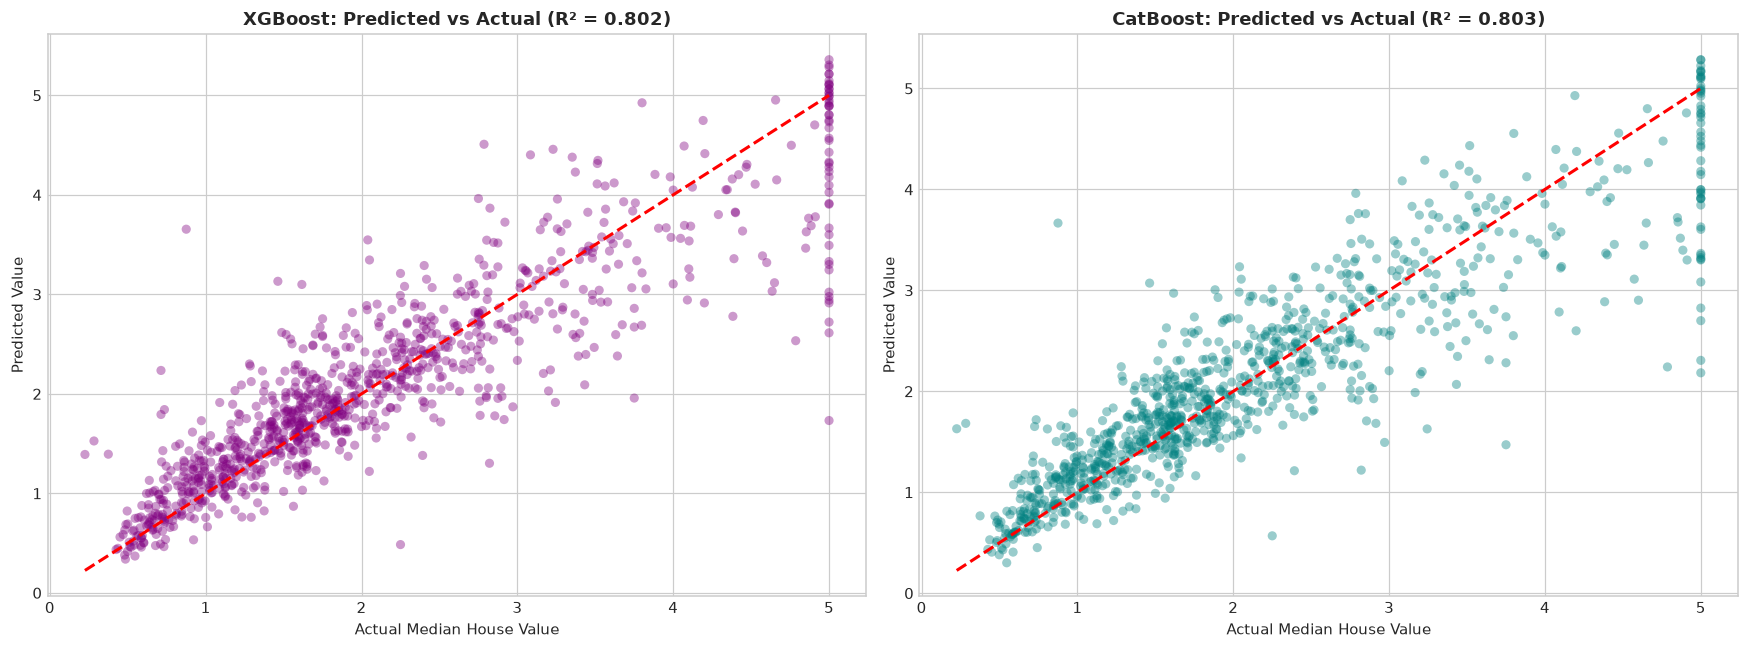

In [8]:
# ---- Predicted vs. actual scatter plots for XGBoost and CatBoost ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost: points close to the red diagonal line mean accurate predictions
ax1.scatter(y_test_reg, y_pred_xgb, alpha=0.4, color='purple', edgecolors='none')
ax1.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax1.set_title(f"XGBoost: Predicted vs Actual (R² = {r2_xgb:.3f})", fontweight='bold')
ax1.set_xlabel("Actual Median House Value")
ax1.set_ylabel("Predicted Value")

# CatBoost
ax2.scatter(y_test_reg, y_pred_cb, alpha=0.4, color='teal', edgecolors='none')
ax2.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax2.set_title(f"CatBoost: Predicted vs Actual (R² = {r2_cb:.3f})", fontweight='bold')
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Value")

plt.tight_layout()
plt.show()


## PART 2: Ensemble Classification Benchmark
### Dataset: Heart Disease
Features include both continuous variables (age, blood pressure, cholesterol, max heart rate) and categorical variables (chest pain type, sex, fasting blood sugar).
Target: Presence of heart disease (1 = positive, 0 = negative).


In [9]:
# ---- Load the Heart Disease dataset (real-world classification benchmark) ----
df_clf = pd.read_csv('../data/heart_disease.csv')
print("Heart Disease Dataset Preview:")
display(df_clf.head())

# Separate target and features (handle either 'target' or 'Target' as the column name)
target_col = 'target' if 'target' in df_clf.columns else 'Target'
y_clf = df_clf[target_col].values
X_clf_raw = df_clf.drop(columns=[target_col])

# One-hot encode categorical variables for RFC / XGBoost / AdaBoost
X_clf_encoded = pd.get_dummies(X_clf_raw, drop_first=True)

# Stratified split keeps the disease/no-disease ratio identical in train and test
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_encoded, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

print(f"Classification Training Set: {X_train_clf.shape}, Test Set: {X_test_clf.shape}")


Heart Disease Dataset Preview:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Classification Training Set: (227, 13), Test Set: (76, 13)


### 2.1 Random Forest Classification (RFC)
Each tree casts a unit vote for the most popular class at input $x$:
$$\hat{C}_{\text{RF}}(x) = \arg\max_k \sum_{b=1}^B \mathbb{I}(T_b(x) = k)$$


### Step-by-Step Algorithm (Random Forest Classification)
1. Draw B bootstrap samples and grow a tree per sample (random feature subset at each split).
2. Each tree casts a unit vote for the class at input x.
3. Final prediction = majority vote: Ĉ_RF(x) = argmax_k Σ_b I(T_b(x) = k).
4. Class probabilities = fraction of trees voting for each class (used for ROC-AUC).


In [10]:
# ---- Random Forest Classification (majority vote of trees) ----
rfc = RandomForestClassifier(n_estimators=120, max_depth=8, random_state=42, n_jobs=-1)
rfc.fit(X_train_clf, y_train_clf)

# Predictions and probability of the positive (disease) class
y_pred_rfc = rfc.predict(X_test_clf)
y_prob_rfc = rfc.predict_proba(X_test_clf)[:, 1]

# ---- Evaluate: accuracy, F1 and ROC-AUC ----
acc_rfc = accuracy_score(y_test_clf, y_pred_rfc)
f1_rfc = f1_score(y_test_clf, y_pred_rfc)
auc_rfc = roc_auc_score(y_test_clf, y_prob_rfc)

print(f"Random Forest Classifier: Accuracy = {acc_rfc:.4f}, F1 = {f1_rfc:.4f}, ROC-AUC = {auc_rfc:.4f}")


Random Forest Classifier: Accuracy = 0.7763, F1 = 0.8046, ROC-AUC = 0.8704


### 2.2 AdaBoost Classification
Sequential boosting where each sample receives a probability weight $w_i$.
At each stage $m$, weak learner $h_m(x)$ is trained, and learner weight is computed:
$$\alpha_m = \frac{1}{2} \ln \left( \frac{1 - \epsilon_m}{\epsilon_m} \right)$$
Points misclassified have weights magnified: $w_i^{(m+1)} = w_i^{(m)} \exp(-\alpha_m y_i h_m(x_i))$.


### Step-by-Step Algorithm (AdaBoost Classification)
1. Initialize sample weights w_i = 1/N.
2. Train a weak learner h_m (decision stump) on the weighted samples.
3. Compute its weighted error ε_m and learner weight α_m = ½ ln((1 − ε_m)/ε_m).
4. Update sample weights: w_i ← w_i · exp(−α_m y_i h_m(x_i)).
5. Repeat for M rounds; final prediction = sign(Σ α_m h_m(x)).


In [11]:
# ---- AdaBoost Classification (re-weighted weak learners) ----
# Misclassified samples get larger weights, so each new stump focuses on hard cases.
ada_clf = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada_clf.fit(X_train_clf, y_train_clf)

y_pred_ada_c = ada_clf.predict(X_test_clf)
y_prob_ada_c = ada_clf.predict_proba(X_test_clf)[:, 1]

acc_ada_c = accuracy_score(y_test_clf, y_pred_ada_c)
f1_ada_c = f1_score(y_test_clf, y_pred_ada_c)
auc_ada_c = roc_auc_score(y_test_clf, y_prob_ada_c)

print(f"AdaBoost Classifier:      Accuracy = {acc_ada_c:.4f}, F1 = {f1_ada_c:.4f}, ROC-AUC = {auc_ada_c:.4f}")


AdaBoost Classifier:      Accuracy = 0.7895, F1 = 0.8182, ROC-AUC = 0.8714


### 2.3 XGBoost Classification
Logistic loss $\mathcal{L} = \sum_i [y_i \ln(1 + e^{-\hat{y}_i}) + (1-y_i) \ln(1 + e^{\hat{y}_i})]$ optimized with shrinkage and column subsampling.


### Step-by-Step Algorithm (XGBoost Classification)
1. Use the same gradient-boosted tree procedure as regression, but with the logistic loss.
2. Loss L = Σ [y_i ln(1 + e^(−ŷ_i)) + (1 − y_i) ln(1 + e^(ŷ_i))].
3. Gradients/Hessians of the logistic loss drive the tree growth at every round.
4. Convert the final margin to a probability with the sigmoid function for ROC-AUC.


In [12]:
# ---- XGBoost Classification (logistic loss + regularization) ----
xgb_clf = xgb.XGBClassifier(
    n_estimators=120,
    learning_rate=0.08,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_clf, y_train_clf)

y_pred_xgb_c = xgb_clf.predict(X_test_clf)
y_prob_xgb_c = xgb_clf.predict_proba(X_test_clf)[:, 1]

acc_xgb_c = accuracy_score(y_test_clf, y_pred_xgb_c)
f1_xgb_c = f1_score(y_test_clf, y_pred_xgb_c)
auc_xgb_c = roc_auc_score(y_test_clf, y_prob_xgb_c)

print(f"XGBoost Classifier:       Accuracy = {acc_xgb_c:.4f}, F1 = {f1_xgb_c:.4f}, ROC-AUC = {auc_xgb_c:.4f}")


XGBoost Classifier:       Accuracy = 0.7763, F1 = 0.8132, ROC-AUC = 0.8509


### 2.4 CatBoost Classification (Demonstrating Native Categorical Handling)
CatBoost handles categorical variables directly via **Target Statistics** calculated on random permutations of the dataset, avoiding dimensional explosion caused by one-hot encoding.


### Step-by-Step Algorithm (CatBoost Classification)
1. Identify categorical columns and pass them via `cat_features`.
2. Encode categories internally with **ordered target statistics** computed on random permutations.
3. Build oblivious trees with ordered boosting exactly as in the regression case.
4. Output class probabilities via the softmax/sigmoid of the summed tree values.


In [13]:
# ---- CatBoost Classification with NATIVE categorical handling ----
# Identify categorical columns so CatBoost can process them directly (no one-hot needed)
categorical_cols = X_clf_raw.select_dtypes(include=['object', 'category']).columns.tolist()
# CatBoost requires categorical columns to be string typed
X_raw_cb = X_clf_raw.copy()
for col in categorical_cols:
    X_raw_cb[col] = X_raw_cb[col].astype(str)

# Same stratified split on the RAW feature table (so CatBoost sees the original categories)
X_tr_cb, X_te_cb, y_tr_cb, y_te_cb = train_test_split(
    X_raw_cb, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

# cat_features tells CatBoost which columns to treat as categorical
cb_clf = cb.CatBoostClassifier(
    iterations=150,
    learning_rate=0.08,
    depth=5,
    cat_features=categorical_cols,
    random_seed=42,
    verbose=False
)
cb_clf.fit(X_tr_cb, y_tr_cb)

y_pred_cb_c = cb_clf.predict(X_te_cb)
y_prob_cb_c = cb_clf.predict_proba(X_te_cb)[:, 1]

acc_cb_c = accuracy_score(y_te_cb, y_pred_cb_c)
f1_cb_c = f1_score(y_te_cb, y_pred_cb_c)
auc_cb_c = roc_auc_score(y_te_cb, y_prob_cb_c)

print(f"CatBoost Classifier:      Accuracy = {acc_cb_c:.4f}, F1 = {f1_cb_c:.4f}, ROC-AUC = {auc_cb_c:.4f}")


CatBoost Classifier:      Accuracy = 0.7632, F1 = 0.7955, ROC-AUC = 0.8551

### 2.5 Classification Comparison & ROC Curves

### Classification Evaluation Process
1. Train all four classifiers on the identical stratified split.
2. Predict hard labels (for accuracy/F1) and probabilities (for ROC-AUC).
3. Summarize in one highlighted table and overlay ROC curves for a threshold-independent comparison.
4. Compare feature importances between a bagging model (RF) and a boosting model (XGBoost).


In [14]:
# ---- Side-by-side classification comparison ----
clf_comparison = pd.DataFrame([
    {"Model": "Random Forest Classifier (RFC)", "Accuracy": acc_rfc, "F1-Score": f1_rfc, "ROC-AUC": auc_rfc},
    {"Model": "AdaBoost Classifier",             "Accuracy": acc_ada_c, "F1-Score": f1_ada_c, "ROC-AUC": auc_ada_c},
    {"Model": "XGBoost Classifier",              "Accuracy": acc_xgb_c, "F1-Score": f1_xgb_c, "ROC-AUC": auc_xgb_c},
    {"Model": "CatBoost Classifier",             "Accuracy": acc_cb_c, "F1-Score": f1_cb_c, "ROC-AUC": auc_cb_c}
]).set_index("Model")

print("Ensemble Classification Comparison on Heart Disease:")
# Highlight the best value of every metric
display(clf_comparison.style.highlight_max(subset=['Accuracy', 'F1-Score', 'ROC-AUC'], color='lightgreen'))


Ensemble Classification Comparison on Heart Disease:


,Accuracy,F1-Score,ROC-AUC
Model,,,
Random Forest Classifier (RFC),0.776316,0.804598,0.870383
AdaBoost Classifier,0.789474,0.818182,0.871429
XGBoost Classifier,0.776316,0.813187,0.850871
CatBoost Classifier,0.763158,0.795455,0.855052


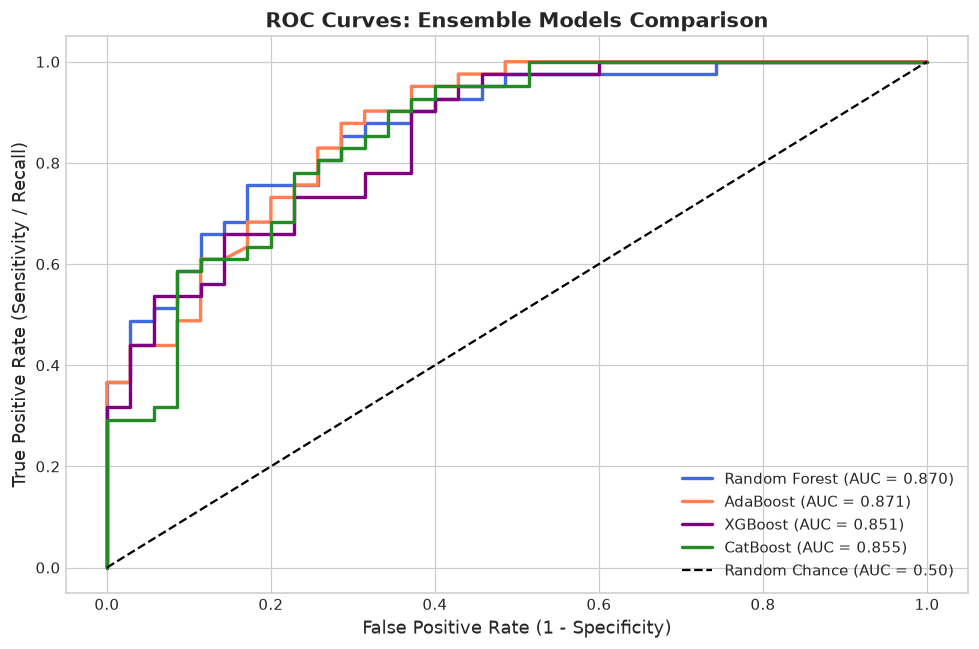

In [15]:
# ---- ROC curves for all four classifiers ----
plt.figure(figsize=(9, 6))

# (label, predicted probabilities, line color)
models_roc = [
    ("Random Forest", y_prob_rfc, 'royalblue'),
    ("AdaBoost",      y_prob_ada_c, 'coral'),
    ("XGBoost",       y_prob_xgb_c, 'purple'),
    ("CatBoost",      y_prob_cb_c, 'forestgreen')
]

for name, probs, col in models_roc:
    fpr, tpr, _ = roc_curve(y_test_clf, probs)          # false/true positive rate at all thresholds
    auc_val = roc_auc_score(y_test_clf, probs)          # area under the curve
    plt.plot(fpr, tpr, color=col, lw=2.2, label=f'{name} (AUC = {auc_val:.3f})')

# Diagonal = random guessing; curves closer to the top-left corner are better
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.50)')
plt.title("ROC Curves: Ensemble Models Comparison", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


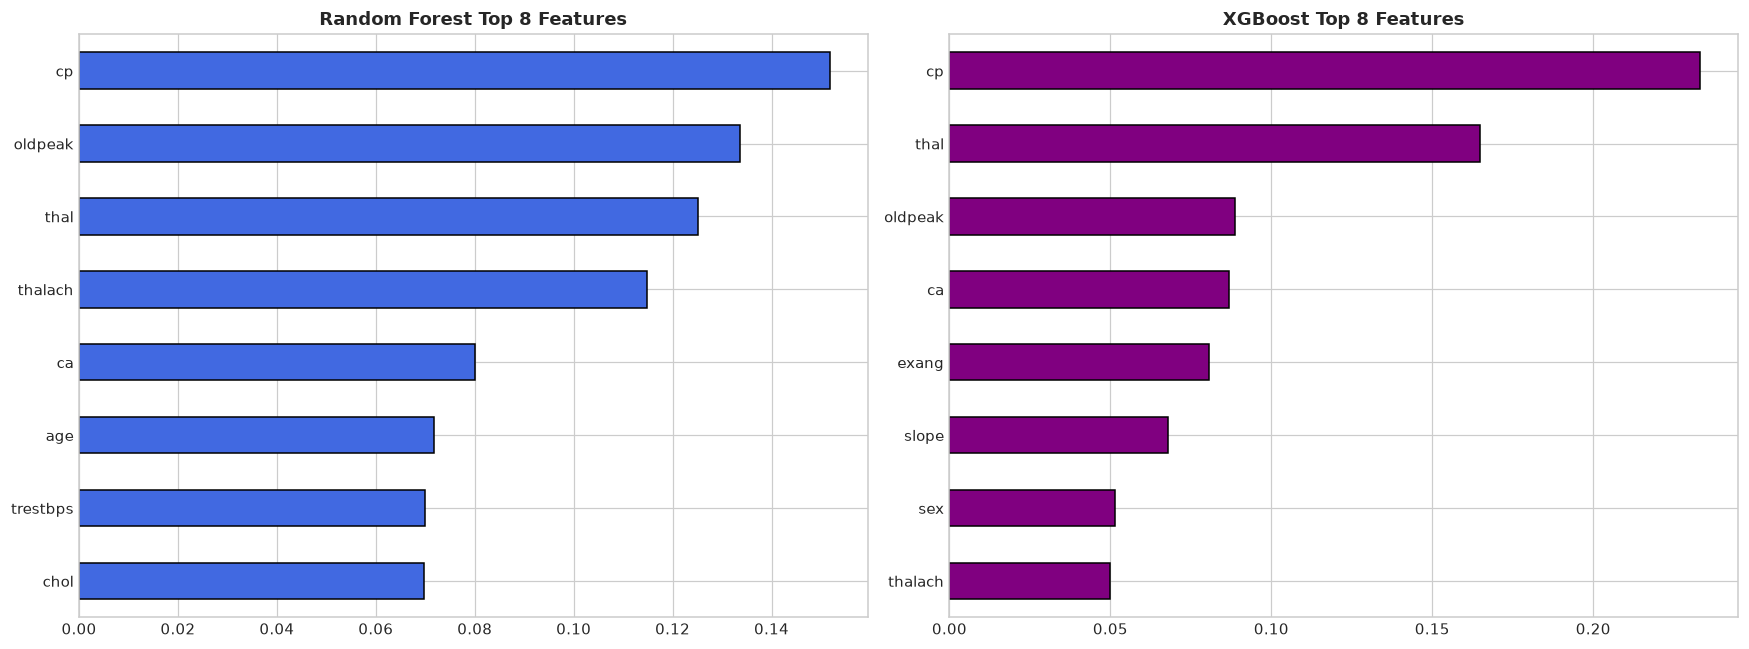

In [16]:
# ---- Feature importance comparison: Random Forest vs XGBoost ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest: mean impurity decrease per feature (top 8)
rf_imp = pd.Series(rfc.feature_importances_, index=X_train_clf.columns).sort_values(ascending=False).head(8)
rf_imp.plot(kind='barh', ax=ax1, color='royalblue', edgecolor='k')
ax1.set_title("Random Forest Top 8 Features", fontweight='bold')
ax1.invert_yaxis()

# XGBoost: gain-based feature importance (top 8)
xgb_imp = pd.Series(xgb_clf.feature_importances_, index=X_train_clf.columns).sort_values(ascending=False).head(8)
xgb_imp.plot(kind='barh', ax=ax2, color='purple', edgecolor='k')
ax2.set_title("XGBoost Top 8 Features", fontweight='bold')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()


## 3. Summary & Practical Guidelines
- **Random Forest (RFR / RFC)**: Robust out-of-the-box baseline with minimal hyperparameter sensitivity, virtually immune to overfitting as trees are added.
- **AdaBoost**: Fast and clean for low-noise datasets, but can be sensitive to outliers due to exponential sample weight amplification.
- **XGBoost**: State-of-the-art tabular speed and accuracy via 2nd-order Taylor expansions and custom regularizers.
- **CatBoost**: Excels especially on tabular datasets containing non-numeric/categorical features, avoiding target leakage and extensive manual preprocessing.
